# Nuclear data uncertainty propagation using the SANDY API

This tutorial shows how to extract, process, and propagate nuclear data uncertainties using the SANDY Python library coupled with NJOY processing tools.

The workflow reflects a complete end‑to‑end path: from raw ENDF‑6 files to covariance sampling, to perturbation of evaluated data.

In [1]:
import sandy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

Note: NumExpr detected 12 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
NumExpr defaulting to 8 threads.


## 1. Reading and Inspecting ENDF‑6 Data

We begin by retrieving the JEFF‑3.3 evaluated nuclear data file for hydrogen‑1 (ZAM=10010) from the [**IAEA archive**](https://www-nds.iaea.org/public/download-endf/).

Basic [**ENDF-6**](https://www.oecd-nea.org/dbdata/data/manual-endf/endf102.pdf) content inspection (MF=3, MT=1, etc.) allowed us to verify that the cross sections were available and correctly formatted.

> ZAM = Z $\times$ 10000 + A $\times$ 10 + M
> 
> - Z: charge number
> - A: mass number
> - M: metastate (0=ground state, 1=first metastate, ...)
> 
> For H-1, ZAM=10010
> 
> For U-235, ZAM=922350
> 
> For Am-242m, ZAM=952421

In [2]:
endf = sandy.get_endf6_file("jeff_33", "xs", 10010)

In [3]:
endf

MAT  MF  MT 
125  1   451     1.001000+3 9.991673-1          0          0  ...
     2   151     1.001000+3 9.991673-1          0          0  ...
     3   1       1.001000+3 9.991673-1          0          0  ...
         2       1.001000+3 9.991673-1          0          0  ...
         102     1.001000+3 9.991673-1          0          0  ...
     4   2       1.001000+3 9.991673-1          0          1  ...
     6   102     1.001000+3 9.991673-1          0          2  ...
     33  1       1.001000+3 9.991673-1          0          0  ...
         2       1.001000+3 9.991673-1          0          0  ...
         102     1.001000+3 9.991673-1          0          0  ...
dtype: object

In [4]:
print(endf.data[(125, 3, 1)])

 1.001000+3 9.991673-1          0          0          0          0 125 3  1    1
 0.000000+0 0.000000+0          0          0          2         96 125 3  1    2
         30          5         96          2                       125 3  1    3
 1.000000-5 3.713628+1 2.000000-5 3.224498+1 5.000000-5 2.790478+1 125 3  1    4
 1.000000-4 2.571732+1 2.000000-4 2.417056+1 5.000000-4 2.279806+1 125 3  1    5
 1.000000-3 2.210633+1 2.000000-3 2.161720+1 5.000000-3 2.118318+1 125 3  1    6
 1.000000-2 2.096443+1 2.530000-2 2.076834+1 5.000000-2 2.067250+1 125 3  1    7
 1.000000-1 2.060332+1 2.000000-1 2.055439+1 5.000000-1 2.051095+1 125 3  1    8
 1.000000+0 2.048901+1 2.000000+0 2.047341+1 5.000000+0 2.045928+1 125 3  1    9
 1.000000+1 2.045169+1 2.000000+1 2.044545+1 5.000000+1 2.043707+1 125 3  1   10
 1.000000+2 2.042815+1 2.000000+2 2.041317+1 5.000000+2 2.037161+1 125 3  1   11
 1.000000+3 2.030435+1 2.000000+3 2.017221+1 4.000000+3 1.991433+1 125 3  1   12
 6.000000+3 1.966407+1 8.000

In [5]:
endf.to_file("H1.jeff33")

## 2. Extract cross section data

We reconstructed tabulated **pointwise cross sections** from resonance parameters.

This is done runnning the **RECONR** module of **NJOY**.

The output is a PENDF file, which contains:
 - Linearized cross sections
 - Reconstructed resonance region
 - Continuous energy grid

A 0.1% linearization tolerance (see parameter `err`) is used too speed-up calculations!

In [12]:
pendf = endf.get_pendf(err=0.1, verbose=True)

get_pendf | ZAM=10010 | augmented NJOY kwargs: { 'acer': False,
  'broadr': False,
  'broadr_kws': {'err': 0.1},
  'dryrun': False,
  'gaspr': False,
  'heatr': False,
  'purr': False,
  'reconr_kws': {'err': 0.1},
  'temperatures': [0],
  'thermr': False,
  'thermr_kws': {'err': 0.1},
  'unresr': False}
get_pendf | ZAM=10010 | run NJOY
_run_njoy | ZAM=10010 | NJOY ran in 0.968 s
get_pendf | ZAM=10010 | parsing NJOY PENDF output into Endf6 structure


Extract the cross sections from the PENDF file and plot them to provide an overview of the $\sigma(E)$ behavior for several MT reactions.

In [7]:
xs = sandy.Xs.from_endf6(pendf)

<Axes: xlabel='E'>

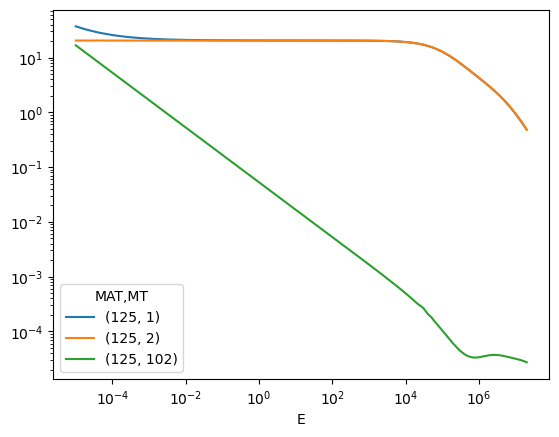

In [8]:
xs.data.plot(logx=True, logy=True)

> What if I want to Doppler-Broaden the cross section at a different temperature?

## 3. Extract covariance data

Covariance data are contained in the ENDF-6 file, but they must be processed to:
- have a unique multi-group structure for all reactions
- reconstruct covariance data when partial contributions are given, e.g., background uncertainty + other uncertainties
- impose constraints if given (total = $\sum$partial)

This is done with **NJOY** (module **ERRORR**) and requires:
- group structure (see parameter `ign`: `ign=4` has 27 groups)
- approximate neutron spectrum (see parameter `iwt`)

The output is a ERRORR file.

In [9]:
errorrs = endf.get_errorr(verbose=True, err=0.1, errorr33_kws=dict(ign=4))

get_errorr | ZAM=10010 | loaded ENDF records: MF present = [ 1  2  3  4  6 33]
get_errorr | ZAM=10010 | augmenting ERRORR NJOY kwargs
get_errorr | ZAM=10010 | augmenting GROUPR NJOY kwargs
get_errorr | ZAM=10010 | covariance availability: MF31=False MF33=True MF34=False MF35=False
get_errorr | ZAM=10010 | covariance processing: MF31=False MF33=True MF34=False MF35=False
get_errorr | ZAM=10010 | running NJOY with augmented kwargs: { 'acer': False,
  'broadr': False,
  'broadr_kws': {'err': 0.1},
  'dryrun': False,
  'errorr31': False,
  'errorr31_kws': {},
  'errorr33': True,
  'errorr33_kws': {'ign': 4},
  'errorr34': False,
  'errorr34_kws': {},
  'errorr35': False,
  'errorr35_kws': {},
  'gaspr': False,
  'groupr_kws': {'chi': False, 'mubar': True, 'nubar': False},
  'heatr': False,
  'purr': False,
  'reconr_kws': {'err': 0.1},
  'temperatures': [0],
  'thermr': False,
  'thermr_kws': {'err': 0.1},
  'unresr': False}
get_errorr | ZAM=10010 | run NJOY
_run_njoy | ZAM=10010 | NJOY ra

Then, extract the covariance matrix from the ERRORR file.

In [13]:
cov = errorrs["errorr33"].get_cov()

### 3.1 Plot the correlation matrix

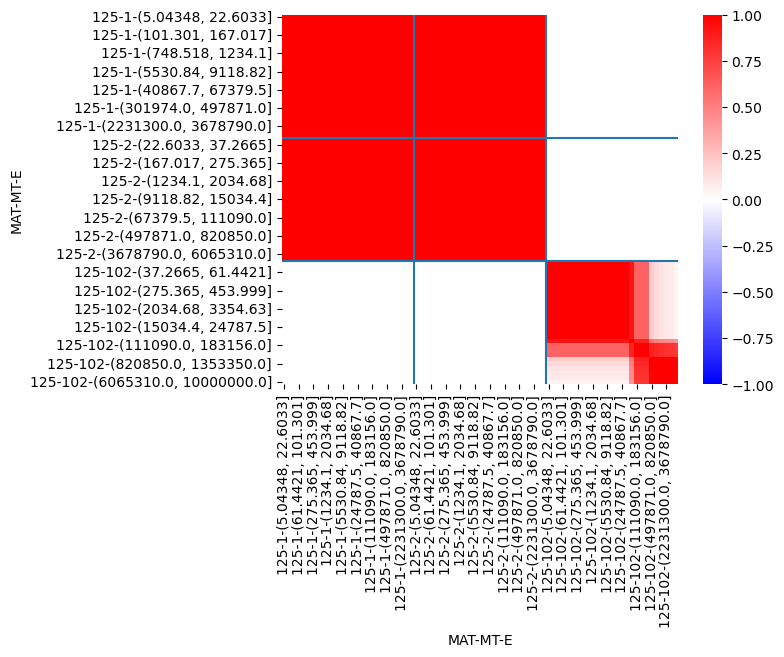

In [14]:
sns.heatmap(data=cov.get_corr().data, vmin=-1, vmax=1, cmap="bwr")
plt.axvline(27)
plt.axhline(27)
plt.axvline(27 * 2)
plt.axhline(27 * 2)

> Can we also plot the covariance matrix?
>
> *Hint*: change `vmin`, `vmax` and `cmap` 

### 3.2 Plot the standard deviation

<Axes: >

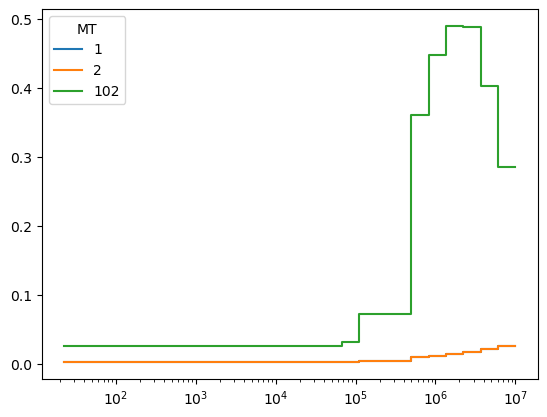

In [17]:
std = cov.get_std().reset_index().pivot_table(index="E", columns="MT", values="STD")
std.index = std.index.right
std.plot(drawstyle="steps-pre", logx=True)

## 4. Draw sample of PDF with given covariance matrix

Take a sample of size $N=10000$. Make it reproducible by fixing the seed.

In [18]:
smp = cov.sampling(10000, seed=1)

Mutltiplicative perturbation coefficients are centered in `1`.

In [20]:
smp.data

SMP                                  0         1         2         3     \
MAT MT  E                                                                 
125 1   (5.04348, 22.6033]       1.001026  0.995864  0.995182  1.001353   
        (22.6033, 37.2665]       1.001304  0.995935  0.995054  1.001358   
        (37.2665, 61.4421]       1.001268  0.996001  0.995057  1.000646   
        (61.4421, 101.301]       1.000928  0.995654  0.995017  1.001344   
        (101.301, 167.017]       1.001286  0.995739  0.995035  1.001203   
...                                   ...       ...       ...       ...   
    102 (820850.0, 1353350.0]    1.058410  1.295100  1.000809  0.519206   
        (1353350.0, 2231300.0]   1.040203  1.245957  0.965192  0.512831   
        (2231300.0, 3678790.0]   1.039746  1.323950  1.062179  0.506294   
        (3678790.0, 6065310.0]   1.083197  1.275736  1.074886  0.545956   
        (6065310.0, 10000000.0]  1.025954  1.231644  1.182818  0.649566   

SMP                                  4         5         6         7     \
MAT MT  E                                                                 
125 1   (5.04348, 22.6033]       1.000134  1.003639  1.006347  1.002682   
        (22.6033, 37.2665]       1.000356  1.003201  1.006313  1.002203   
        (37.2665, 61.4421]       1.000307  1.003159  1.006637  1.002174   
        (61.4421, 101.301]       1.000235  1.003339  1.005999  1.002333   
        (101.301, 167.017]       1.000486  1.003276  1.006300  1.002401   
...                                   ...       ...       ...       ...   
    102 (820850.0, 1353350.0]    1.451457  1.078522  0.709662  1.224370   
        (1353350.0, 2231300.0]   1.352518  1.095707  0.691016  1.196103   
        (2231300.0, 3678790.0]   1.322801  1.094287  0.701274  1.120892   
        (3678790.0, 6065310.0]   1.280361  1.147751  0.765508  1.064137   
        (6065310.0, 10000000.0]  1.187750  1.169550  0.816169  1.014673   

SMP                                  8         9     ...      9990      9991  \
MAT MT  E                                            ...                       
125 1   (5.04348, 22.6033]       0.997338  1.004664  ...  1.005425  1.001196   
        (22.6033, 37.2665]       0.997646  1.004590  ...  1.005529  1.000964   
        (37.2665, 61.4421]       0.997057  1.004423  ...  1.005157  1.000775   
        (61.4421, 101.301]       0.997467  1.004515  ...  1.005346  1.001442   
        (101.301, 167.017]       0.997460  1.004749  ...  1.005497  1.001546   
...                                   ...       ...  ...       ...       ...   
    102 (820850.0, 1353350.0]    1.118047  0.996914  ...  0.595919  2.335540   
        (1353350.0, 2231300.0]   1.023984  0.974366  ...  0.519826  2.473024   
        (2231300.0, 3678790.0]   1.041384  1.081093  ...  0.508821  2.494798   
        (3678790.0, 6065310.0]   1.073825  1.085001  ...  0.566818  2.200042   
        (6065310.0, 10000000.0]  1.063566  1.070492  ...  0.686782  1.725593   

SMP                                  9992      9993      9994      9995  \
MAT MT  E                                                                 
125 1   (5.04348, 22.6033]       1.000548  0.996207  0.997144  0.998899   
        (22.6033, 37.2665]       1.000801  0.995708  0.997021  0.999732   
        (37.2665, 61.4421]       1.000768  0.995815  0.996993  0.999178   
        (61.4421, 101.301]       1.000517  0.996104  0.997037  0.999197   
        (101.301, 167.017]       1.000370  0.996146  0.996794  0.998936   
...                                   ...       ...       ...       ...   
    102 (820850.0, 1353350.0]    0.816833  0.562531  0.355529  1.687952   
        (1353350.0, 2231300.0]   0.822364  0.553287  0.306655  1.677254   
        (2231300.0, 3678790.0]   0.753610  0.550071  0.310511  1.742208   
        (3678790.0, 6065310.0]   0.770423  0.611122  0.394034  1.639582   
        (6065310.0, 10000000.0]  0.873886  0.731394  0.490234  1.447289   

SMP                            

> Can you plot the sample distribution of one parameter?

## 5. Analyze convergence

Compute the **sample standard deviation** for each reaction and visualize how this sample‑based estimate compares to the true or reference standard deviation.

The sample estimate can be computed over different samples sizes by changing this parameter.

In [24]:
selected_sample_size = 10000

<Axes: >

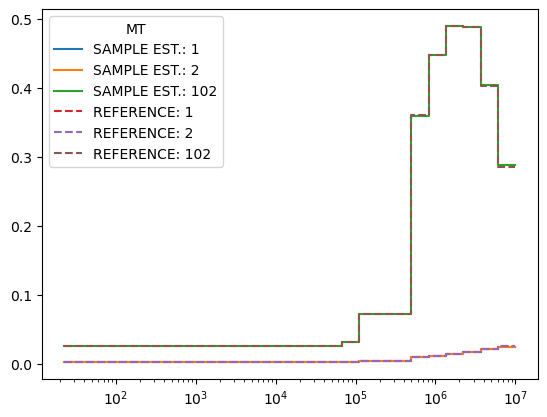

In [25]:
# plot sample estimate
sstd = smp.data.iloc[:, :selected_sample_size].std(axis=1).rename("STD").reset_index().pivot_table(index="E", columns="MT", values="STD")
sstd.index = sstd.index.right
ax = sstd.add_prefix("SAMPLE EST.: ").plot(drawstyle="steps-pre", logx=True)

# plot reference standard deviation
std.add_prefix("REFERENCE: ").plot(drawstyle="steps-pre", ls="--", logx=True, ax=ax)

---

When working with a sequence of data points $x_1, x_2, \dots, x_n$, it can be useful to see how statistical measures evolve as more data is added.

This is exactly what the running mean and running standard deviation show.

**Running mean**

The running mean (also called the **cumulative mean**) at position $i$ is the mean of the first $i$ values:

$$
\mathrm{running\;mean}(i) = \frac{1}{i} \sum_{k=1}^i x_k
$$

This tells you:

- how the average changes as new observations come in
- how quickly the average stabilizes
- whether early values dominate or later values pull the mean in a new direction

If the dataset is stable, the running mean will gradually converge to the final mean.

**Running standard deviation**

It measures how spread out the first $i$ data points are, i.e.,

$$
\mathrm{running\;std}(i) = \sqrt{ \frac{1}{i-1} \sum_{k=1}^i \left( x_k - \mathrm{running\;mean(i)} \right)^2 }
$$

This helps you see:

- how the variability changes as more data arrives
- whether the distribution initially appears noisy but stabilizes over time
- how many samples are needed before the standard deviation becomes reliable

Like the running mean, the running standard deviation typically becomes more stable as the sample size increases.

Here we compute and visualize how the running mean and running standard deviation evolve for a selected parameter:

In [28]:
idx = 0
x = smp.data.iloc[idx]
running_mean = pd.Series({i: np.mean(x[:i]) for i in range(2, len(x)+1)})
running_std = pd.Series({i: np.std(x[:i]) for i in range(2, len(x)+1)})

Both running statistics are then normalized by dividing by their final value.
This allows comparing their relative convergence behavior on the same scale.

This helps illustrate how statistical estimators (mean, std) converge as sample size increases.

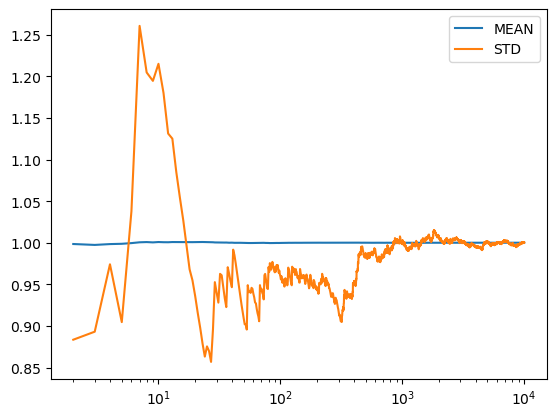

In [29]:
(running_mean / running_mean.iloc[-1]).plot(label="MEAN", logx=True)
(running_std / running_std.iloc[-1]).plot(label="STD", logx=True)
plt.legend()

Running statistics show convergence behavior:

- With few data points: both mean and std fluctuate a lot.
- With more data: they settle toward their “true” values.

Plotting them (especially on a log x‑scale) helps visualize how fast these estimates stabilize.